
--- Available keys in loaded NPZ files ---
File: IndoBERT_Norm_PR.npz, Keys: ['recall', 'precision', 'auc']
File: IndoBERT_Reg_PR.npz, Keys: ['recall', 'precision', 'auc']
File: SVM_Norm_PR.npz, Keys: ['recall', 'precision', 'auc']
File: SVM_Reg_PR.npz, Keys: ['recall', 'precision', 'auc']
File: NB_Norm_PR.npz, Keys: ['recall', 'precision', 'auc']
File: NB_Reg_PR.npz, Keys: ['recall', 'precision', 'auc']
------------------------------------------



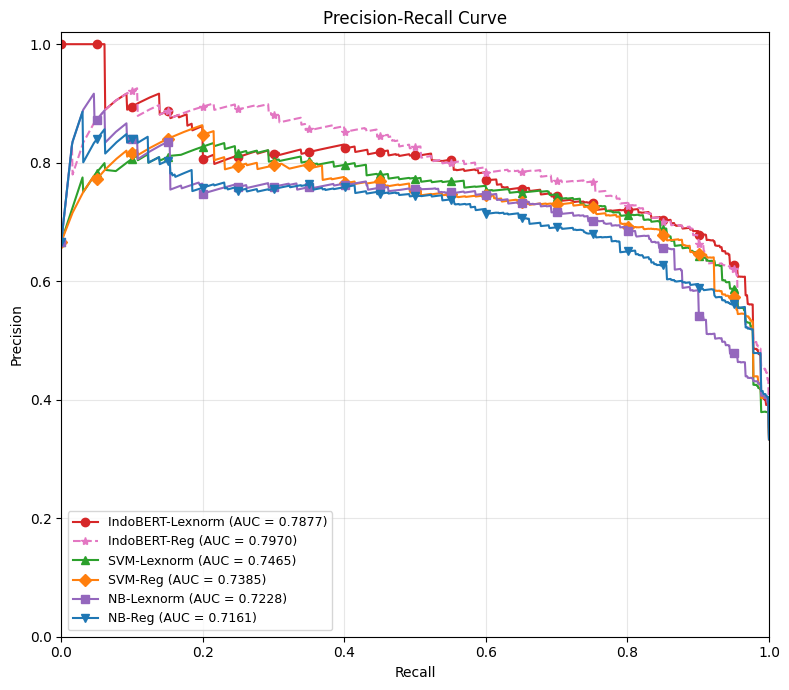

Saved combined_pr_curve.png


In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt

save_dir = "/content/drive/MyDrive/Thesis/results/pr_data"

model_names = [
    "IndoBERT-Lexnorm",
    "IndoBERT-Reg",
    "SVM-Lexnorm",
    "SVM-Reg",
    "NB-Lexnorm",
    "NB-Reg",
]
File_names = [
    "IndoBERT_Norm_PR",
    "IndoBERT_Reg_PR",
    "SVM_Norm_PR",
    "SVM_Reg_PR",
    "NB_Norm_PR",
    "NB_Reg_PR",
]

styles = {
    "IndoBERT-Lexnorm": dict(color="#d62728", marker="o", linestyle="-"),
    "IndoBERT-Reg": dict(color="#e377c2", marker="*", linestyle="--"),
    "SVM-Lexnorm":      dict(color="#2ca02c", marker="^", linestyle="-"),
    "SVM-Reg":      dict(color="#ff7f0e", marker="D", linestyle="-"),
    "NB-Lexnorm":       dict(color="#9467bd", marker="s", linestyle="-"),
    "NB-Reg":       dict(color="#1f77b4", marker="v", linestyle="-"),
}

loaded = {}
for name in File_names:
    path = os.path.join(save_dir, f"{name}.npz")
    if not os.path.exists(path):
        print(f"WARNING: missing {path} -- skipping {name}")
        continue
    loaded[name] = np.load(path)

# Print available keys in each loaded file
print("\n--- Available keys in loaded NPZ files ---")
for file_name, data in loaded.items():
    print(f"File: {file_name}.npz, Keys: {list(data.keys())}")
print("------------------------------------------\n")

# Create a mapping from File_name (keys in `loaded`) to model_name (keys in `styles`)
file_to_model_map = dict(zip(File_names, model_names))

# ---------------- PR comparison plot ----------------
plt.figure(figsize=(8, 7))
for file_name, data in loaded.items():
    model_name = file_to_model_map.get(file_name) # Get the corresponding model name
    if model_name is None:
        print(f"WARNING: No model name found for file {file_name}")
        continue
    recall, precision, pr_auc = data["recall"], data["precision"], float(data["auc"])
    style = styles.get(model_name, {}) # Use model_name for styles lookup
    plt.plot(
        recall, precision,
        label=f"{model_name} (AUC = {pr_auc:.4f})", # Use model_name for label
        markevery=max(len(recall) // 20, 1),
        markersize=6, linewidth=1.5,
        **style,
    )
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend(loc="lower left", fontsize=9)
plt.grid(alpha=0.3)
plt.xlim(0, 1); plt.ylim(0, 1.02)
plt.tight_layout()
plt.savefig("combined_pr_curve.png", dpi=200)
plt.show()

print("Saved combined_pr_curve.png")